/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped_test/
Plotting dem
Plotting slope
Plotting y_aspect
Plotting x_aspect
Plotting svf
Plotting tvf
Plotting hor_n
Plotting hor_w
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_terrain_test025_old_all_cids_new.png


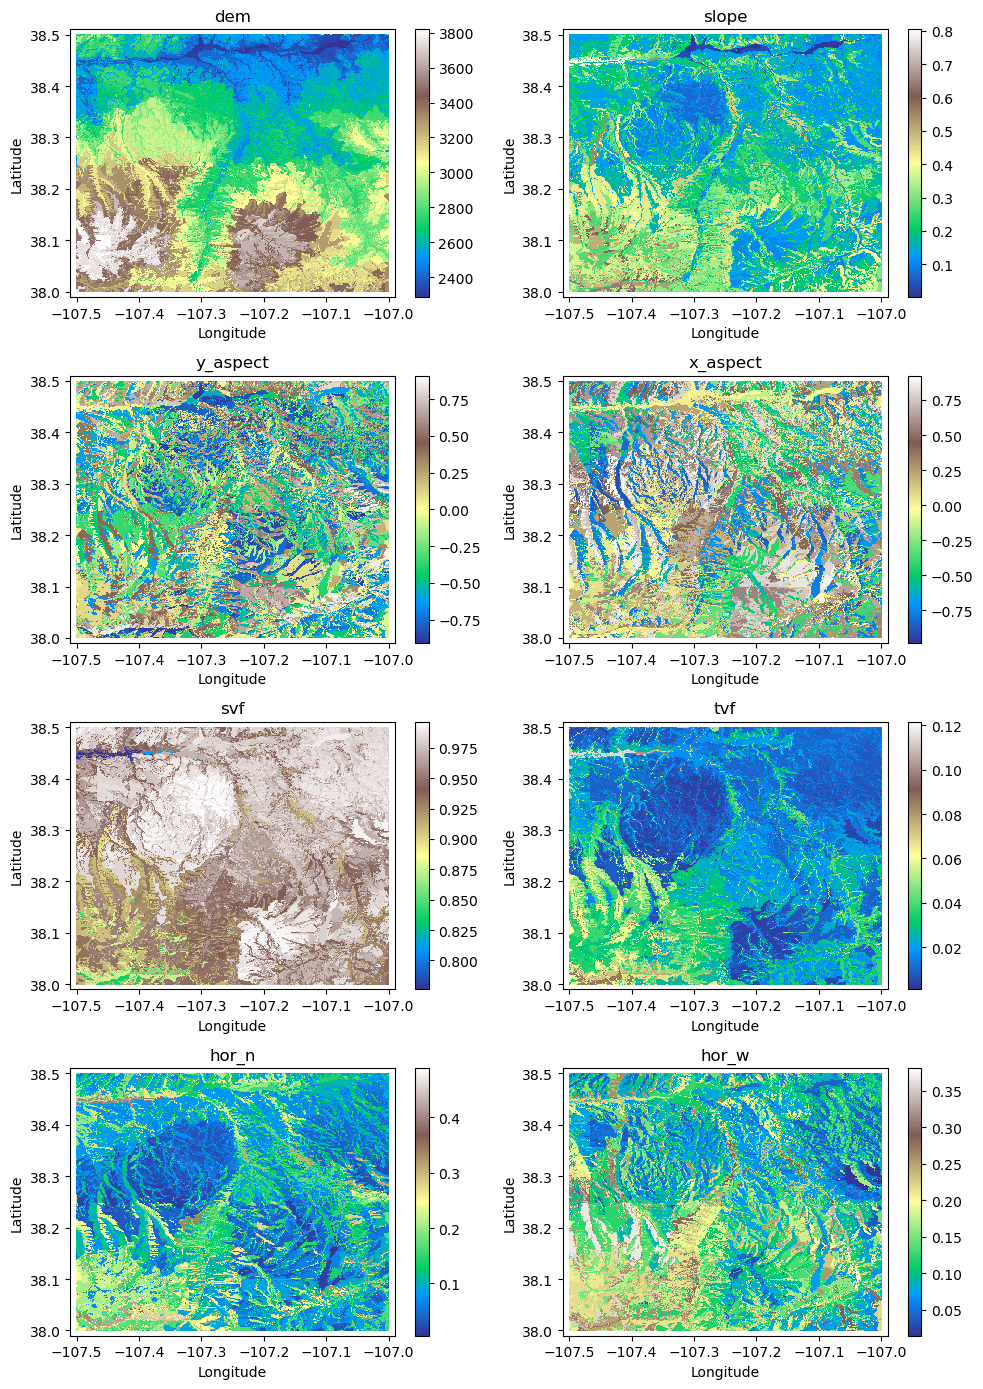

In [5]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools
# Output path
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

# Simulation path
path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped_test/"

print(path)

# Read HRU and CID maps
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

# Coordinate axes
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0
coords_y = coord_yy0

# Function to place HRU data on raster grid
def place_data(final_map, model, hrus, cids, val):
    for i in range(final_map.shape[0]):
        for j in range(final_map.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru != -9999) and (ucid == val):
                final_map[i, j] = model[hru]

    return final_map

# Variables to plot
var2plot = ["dem", "slope","y_aspect", "x_aspect","svf", "tvf","hor_n", "hor_w"]

cid_list = [1, 2, 3, 4]

# Plot
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
axes = axes.flatten()

for j, ax in enumerate(axes):

    var = var2plot[j]
    print(f"Plotting {var}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"{c}/input_file.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)

        grp = fp.groups["parameters"]
        data = np.array(grp.variables[var][:])

        fp.close()

        final_map = place_data(final_map, data, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    # Valid-data extent with small no-data border
    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="terrain",
        shading="auto"
    )

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax)

plt.tight_layout()

outfile = os.path.join(outputdir, "res_terrain_test025_old_all_cids_new.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_smc_surface_seasonal_PP_test025_unflipped_auto_scale_new.png


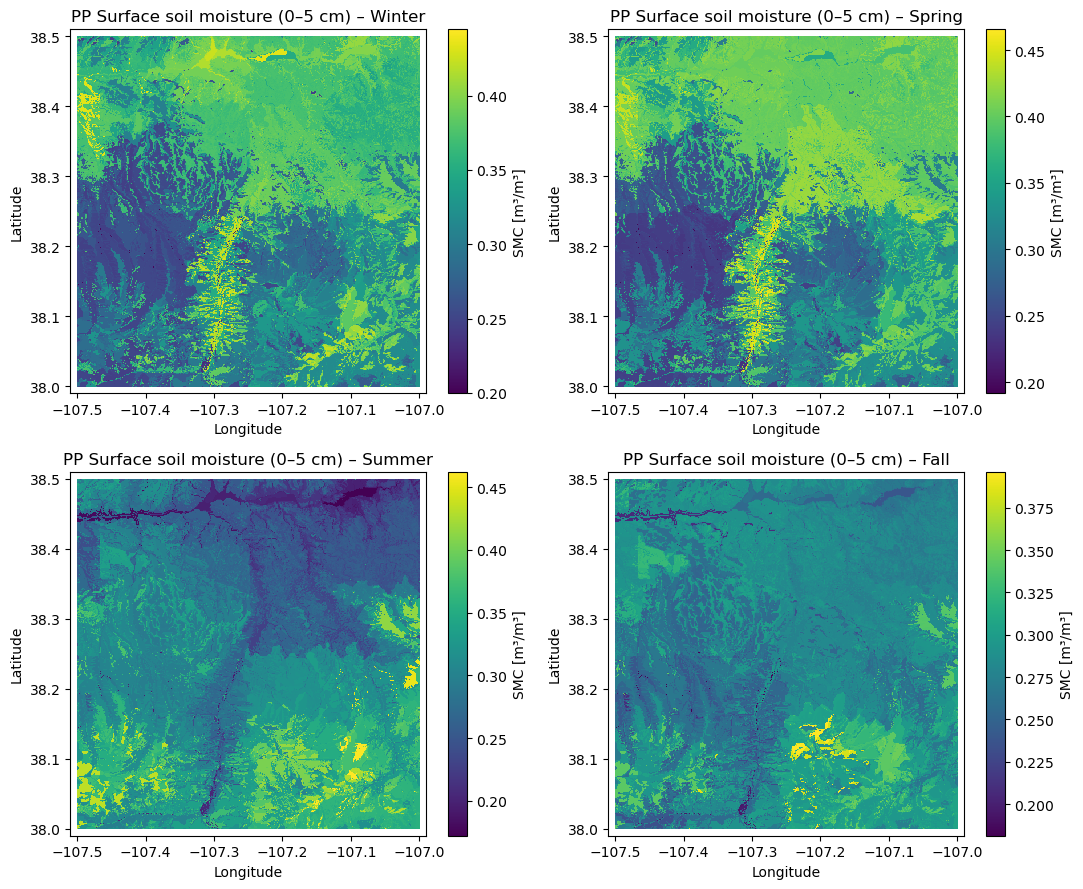

In [6]:
# SOIL MOISTURE (SMC) SEASONAL PLOTS — TOP LAYER — PP — 4 CIDS

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

cid_list = [1, 2, 3, 4]

# Build datetime from input_file.nc time
fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):

    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"output_data/{c}/2014-01-01.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)
        smc = np.array(fp.groups["data"].variables["smc"][:])
        fp.close()

        # Top soil layer: 0–5 cm
        data = smc[:, :, 0]

        times_index = times.dt.month.isin(my_months)
        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)

        final_map = place_data(final_map, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        shading="auto"
    )

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "res_smc_surface_seasonal_PP_test025_unflipped_auto_scale_new.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()

Creating FSNO plot for Winter
Creating FSNO plot for Spring
Creating FSNO plot for Summer
Creating FSNO plot for Fall
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_fsno_seasonal_PP_test025_unflipped_fixed_scale_new.png


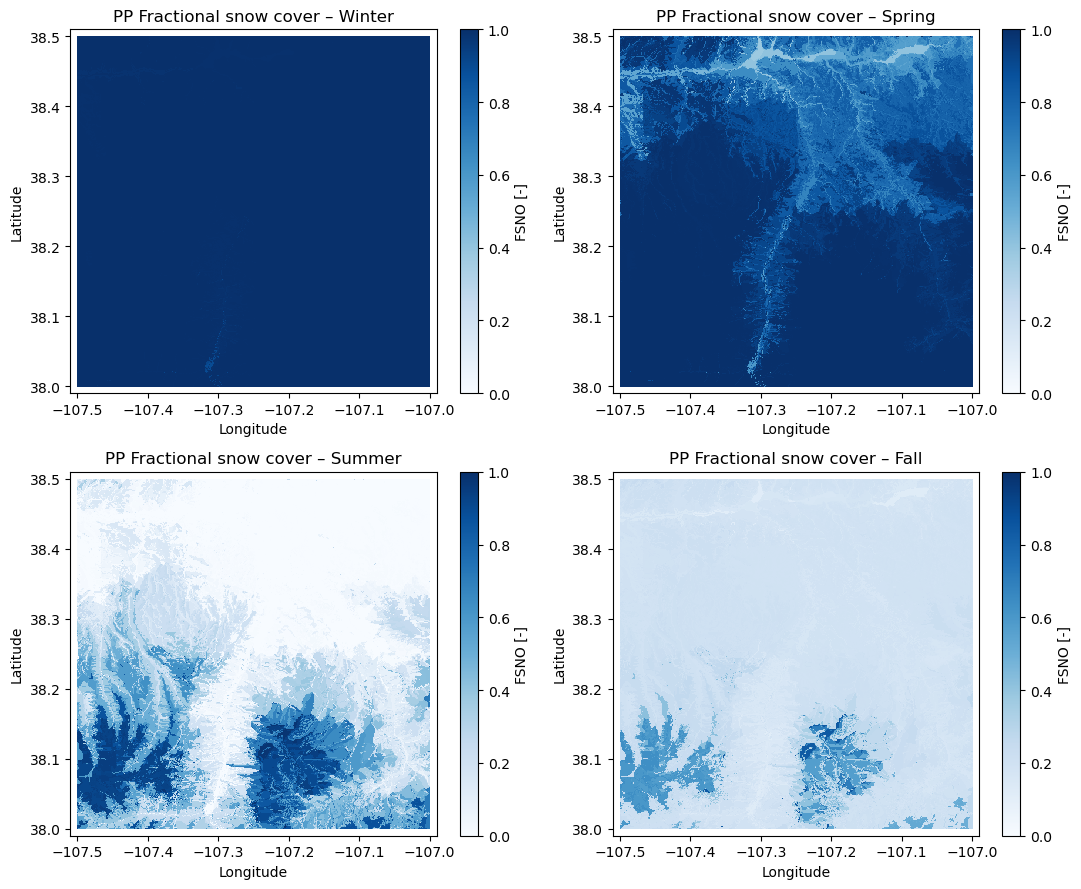

In [3]:
# ============================================================
# FRACTIONAL SNOW COVER (FSNO) SEASONAL PLOTS — PP — 4 CIDS
# ============================================================

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]
cid_list = [1, 2, 3, 4]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):

    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating FSNO plot for {my_season}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"output_data/{c}/2014-01-01.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)
        fsno = np.array(fp.groups["data"].variables["fsno"][:])
        fp.close()

        times_index = times.dt.month.isin(my_months)
        data_sel = fsno[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)

        final_map = place_data(final_map, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="Blues",
        vmin=0,
        vmax=1,
        shading="auto"
    )

    ax.set_title(f"PP Fractional snow cover – {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="FSNO [-]")

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "res_fsno_seasonal_PP_test025_unflipped_fixed_scale_new.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()

Creating seasonal plots for swdown
  swdown: Winter
  swdown: Spring
  swdown: Summer
  swdown: Fall
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_swdown_seasonal_PP_test025_unflipped.png


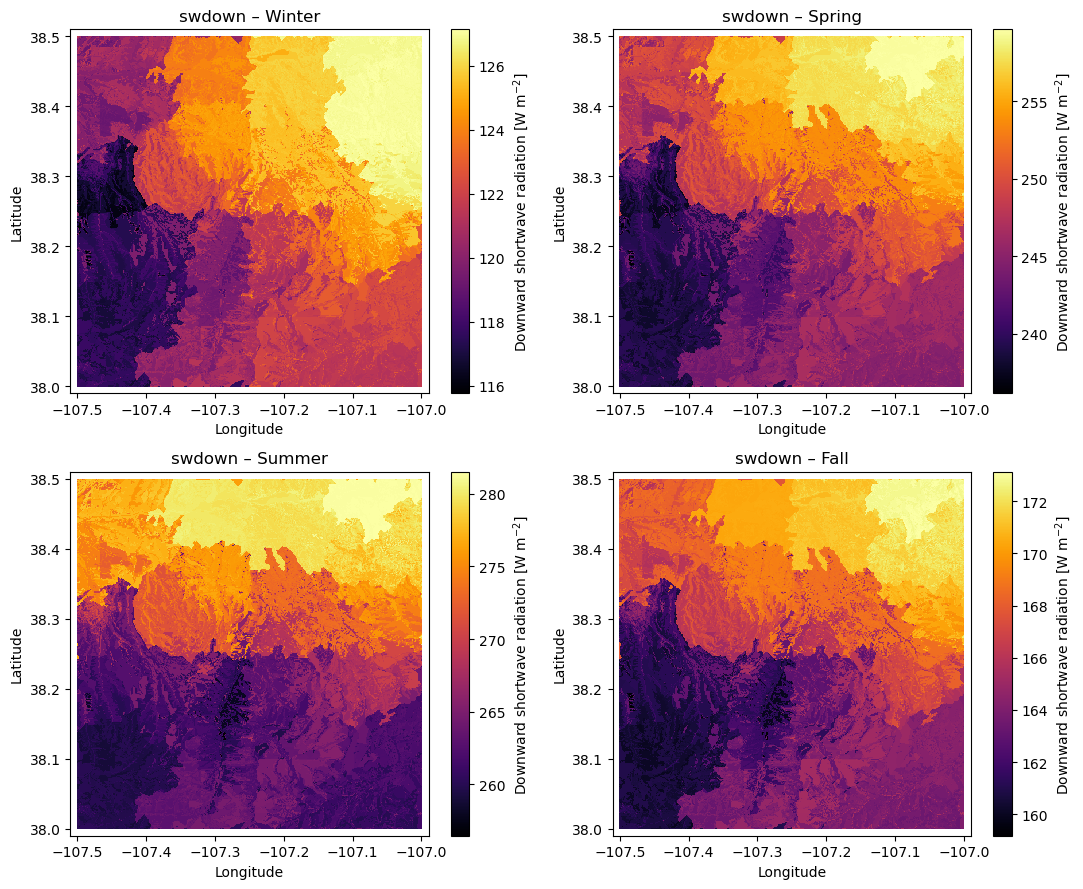

Creating seasonal plots for lwdown
  lwdown: Winter
  lwdown: Spring
  lwdown: Summer
  lwdown: Fall
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_lwdown_seasonal_PP_test025_unflipped.png


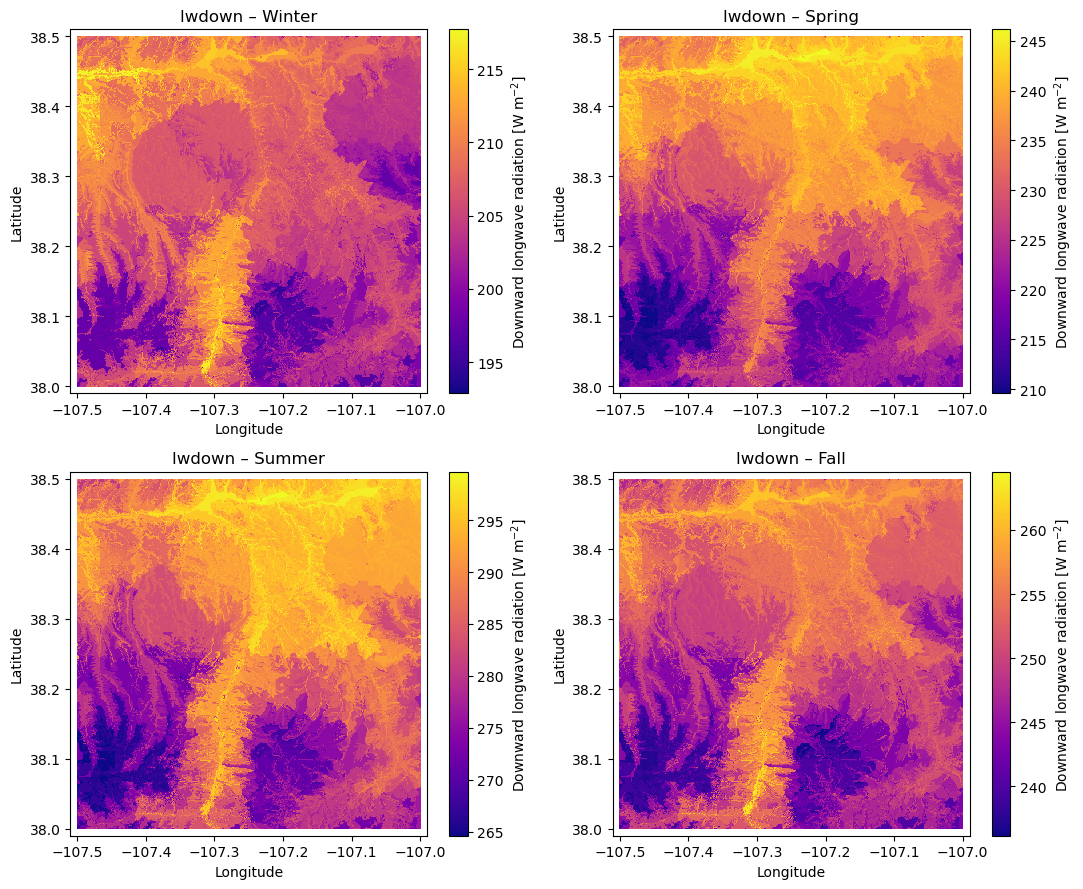

Creating seasonal plots for tair
  tair: Winter
  tair: Spring
  tair: Summer
  tair: Fall
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_tair_seasonal_PP_test025_unflipped.png


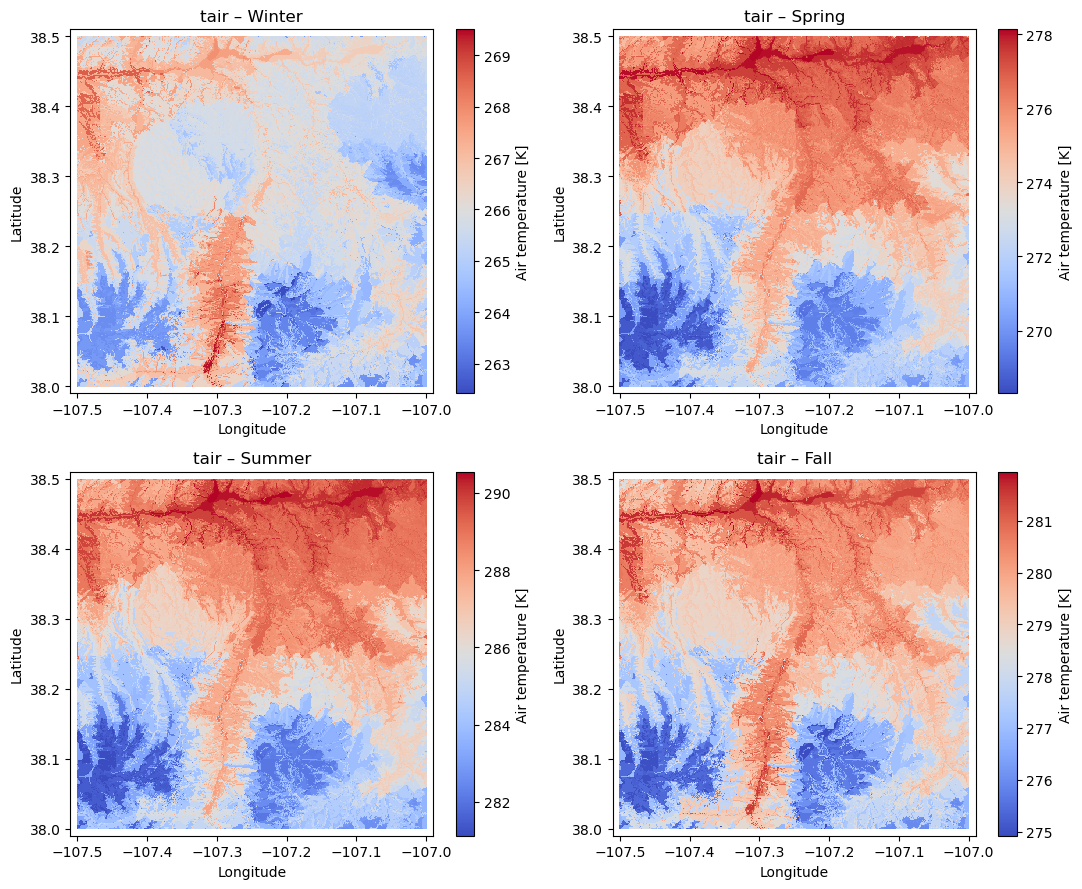

Creating seasonal plots for precip
  precip: Winter
  precip: Spring
  precip: Summer
  precip: Fall
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_precip_seasonal_PP_test025_unflipped.png


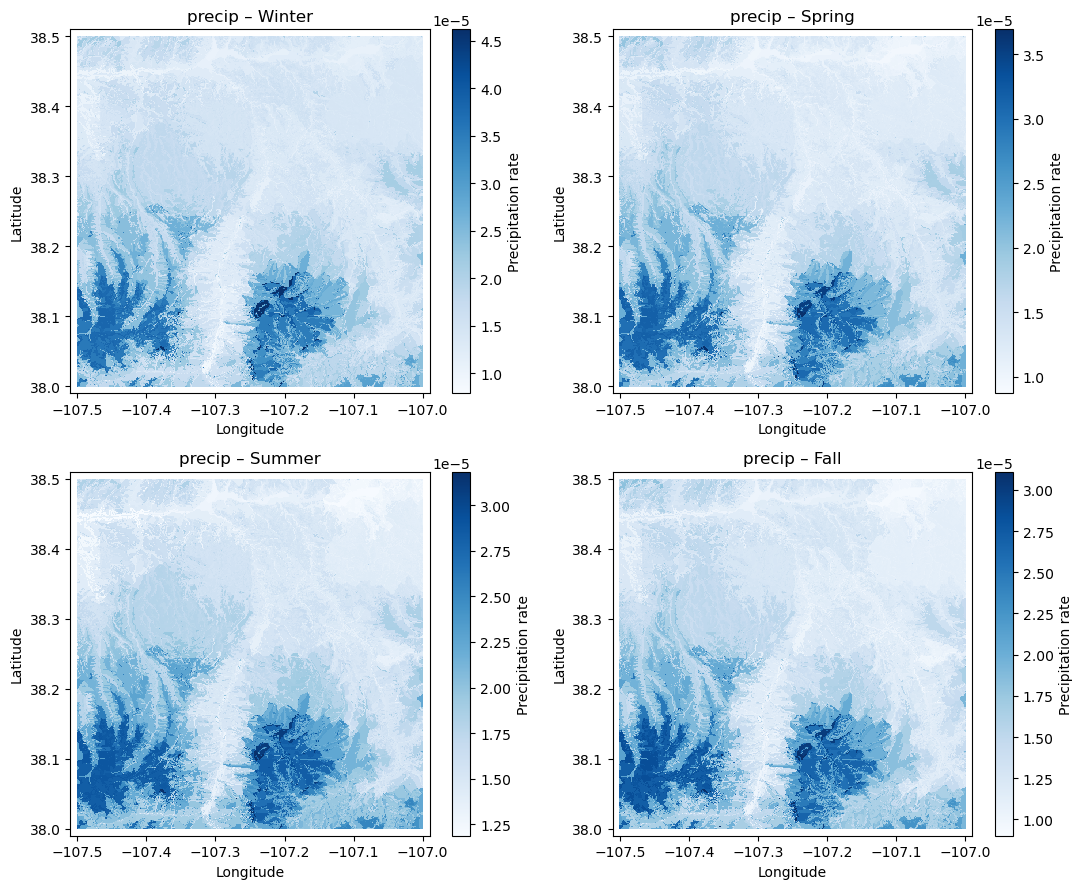

Creating seasonal plots for psurf
  psurf: Winter
  psurf: Spring
  psurf: Summer
  psurf: Fall
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_psurf_seasonal_PP_test025_unflipped.png


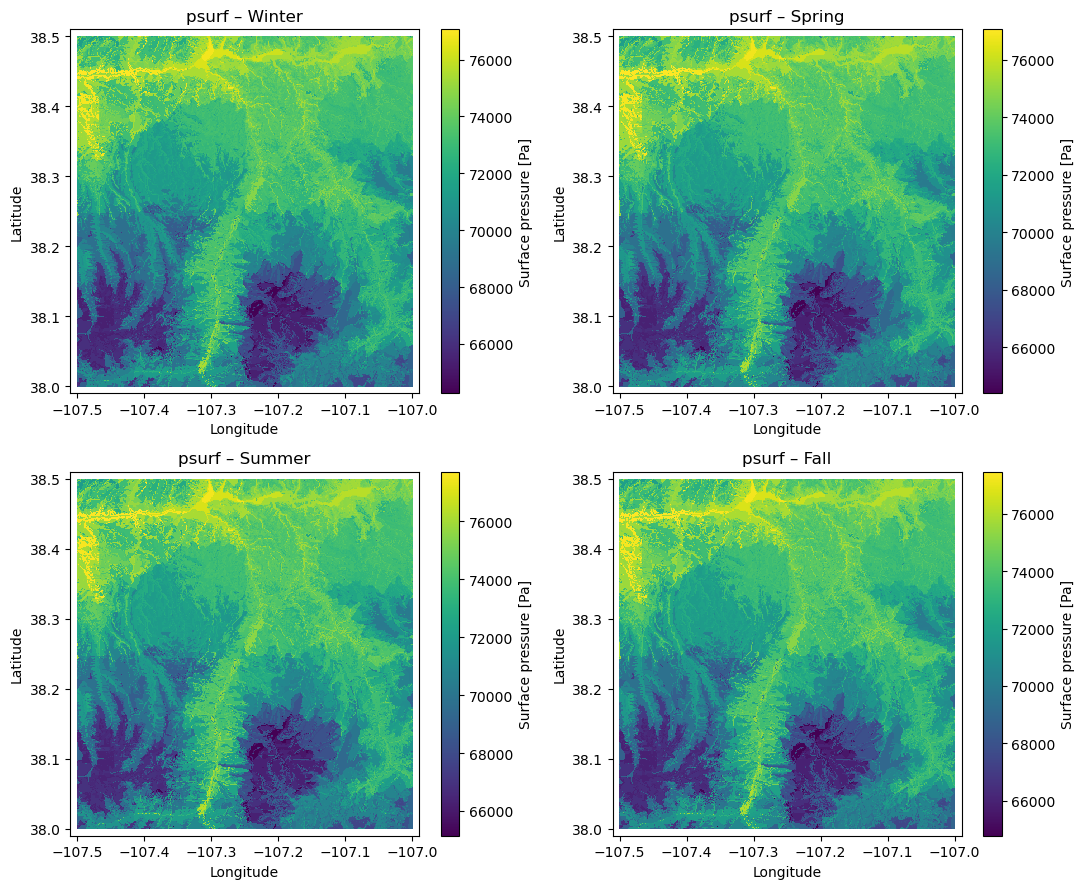

Creating seasonal plots for spfh
  spfh: Winter
  spfh: Spring
  spfh: Summer
  spfh: Fall
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_spfh_seasonal_PP_test025_unflipped.png


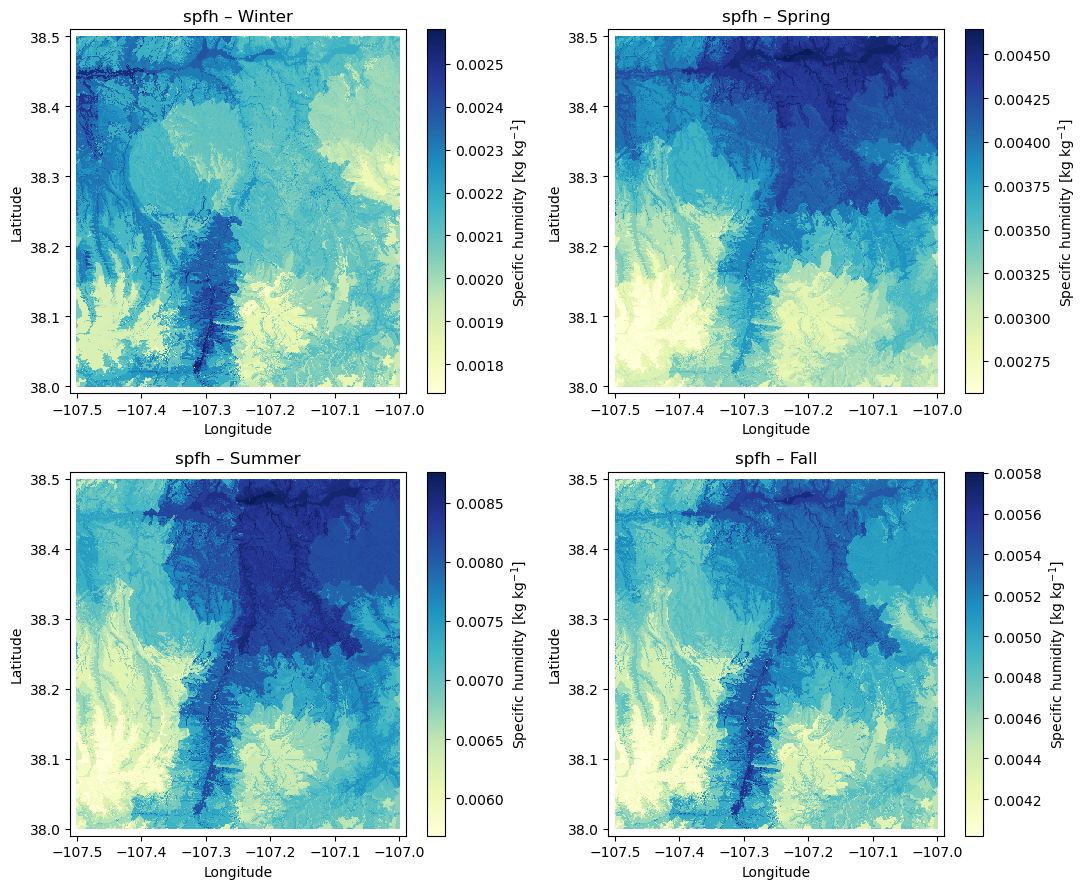

In [4]:
# METEOROLOGY SEASONAL PLOTS — PP — 4 CIDS
# swdown, lwdown, tair, precip, psurf, spfh

var2plot = ["swdown", "lwdown", "tair", "precip", "psurf", "spfh"]

var_labels = {
    "swdown": "Downward shortwave radiation [W m$^{-2}$]",
    "lwdown": "Downward longwave radiation [W m$^{-2}$]",
    "tair": "Air temperature [K]",
    "precip": "Precipitation rate",
    "psurf": "Surface pressure [Pa]",
    "spfh": "Specific humidity [kg kg$^{-1}$]",
}

var_cmaps = {
    "swdown": "inferno",
    "lwdown": "plasma",
    "tair": "coolwarm",
    "precip": "Blues",
    "psurf": "viridis",
    "spfh": "YlGnBu",
}

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]
cid_list = [1, 2, 3, 4]

for var in var2plot:

    print(f"Creating seasonal plots for {var}")

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    axes = axes.flatten()

    for iss, ax in enumerate(axes):

        my_season = seasons[iss]
        my_months = season_months[iss]

        print(f"  {var}: {my_season}")

        final_map = np.copy(hrus).astype(float)
        final_map[:] = -9999.0

        for c in cid_list:

            fp_path = path + f"{c}/input_file.nc"

            if not os.path.exists(fp_path):
                print(f"Missing: {fp_path}")
                continue

            fp = nc.Dataset(fp_path)
            data_all = np.array(fp.groups["meteorology"].variables[var][:])
            fp.close()

            times_index = times.dt.month.isin(my_months)
            data_sel = data_all[times_index, :]
            data_ave = np.nanmean(data_sel, axis=0)

            final_map = place_data(final_map, data_ave, hrus, cids, int(c))

        final_map = np.ma.masked_where(final_map == -9999, final_map)

        valid = ~final_map.mask
        rows, cols = np.where(valid)

        xmin = coords_x[cols.min()]
        xmax = coords_x[cols.max()]
        ymin = coords_y[rows.min()]
        ymax = coords_y[rows.max()]

        pad_x = 0.02 * (xmax - xmin)
        pad_y = 0.02 * (ymax - ymin)

        im = ax.pcolormesh(
            coords_x,
            coords_y,
            np.flipud(final_map),
            cmap=var_cmaps[var],
            shading="auto"
        )

        ax.set_title(f"{var} – {my_season}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        ax.set_xlim(xmin - pad_x, xmax + pad_x)
        ax.set_ylim(ymin - pad_y, ymax + pad_y)

        fig.colorbar(im, ax=ax, label=var_labels[var])

    plt.tight_layout()

    outfile = os.path.join(
        outputdir,
        f"res_{var}_seasonal_PP_test025_unflipped.png"
    )

    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print("Saved:", outfile)

    plt.show()

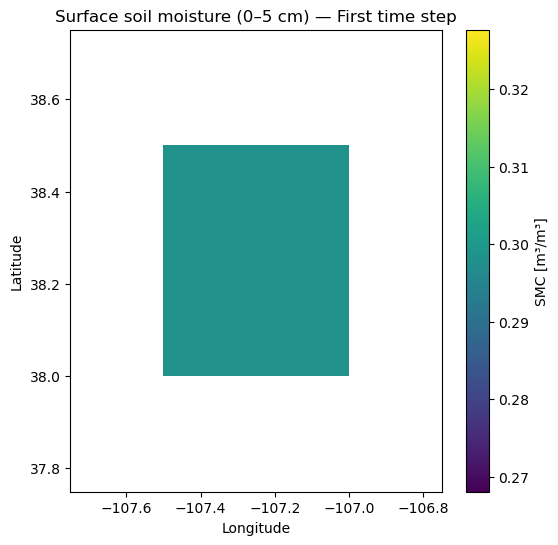

In [2]:
# ==========================================================
# Plot first time step (t = 0)
# ==========================================================

final_map = np.full(hrus.shape, -9999.0, dtype=float)

for c in cid_list:

    fp_path = path + f"output_data/{c}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        continue

    with nc.Dataset(fp_path) as fp:
        smc = fp.groups["data"].variables["smc"][:]

    # First time step, top soil layer
    model = smc[0, :, 0]

    final_map = place_data(final_map, model, hrus, cids, c)

final_map = np.ma.masked_where(final_map == -9999, final_map)

plt.figure(figsize=(6,6))

plt.pcolormesh(
    coords_x,
    coords_y,
    np.flipud(final_map),
    cmap="viridis",
    shading="auto"
)

plt.colorbar(label="SMC [m³/m³]")
plt.title("Surface soil moisture (0–5 cm) — First time step")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_11yrs_100hru_100bh_test_new_test_domain/
Raster metadata: {'proj4': '+proj=longlat +datum=WGS84 +no_defs', 'minx': -107.7504166666655, 'miny': 37.74958333333264, 'maxx': -106.74958333333221, 'maxy': 38.75041666666593, 'resx': 0.0008333333333333, 'resy': -0.0008333333333333, 'gt': (-107.7504166666655, 0.0008333333333333, 0.0, 38.75041666666593, 0.0, -0.0008333333333333), 'nx': 1201, 'ny': 1201, 'projection': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'}
Boundary layer loaded: CRS=epsg:4326, features=294
Raster x range: -107.7504166666655 to -106.74958333333221
Raster y range: 37.74958333333264 to 38.75041666666593

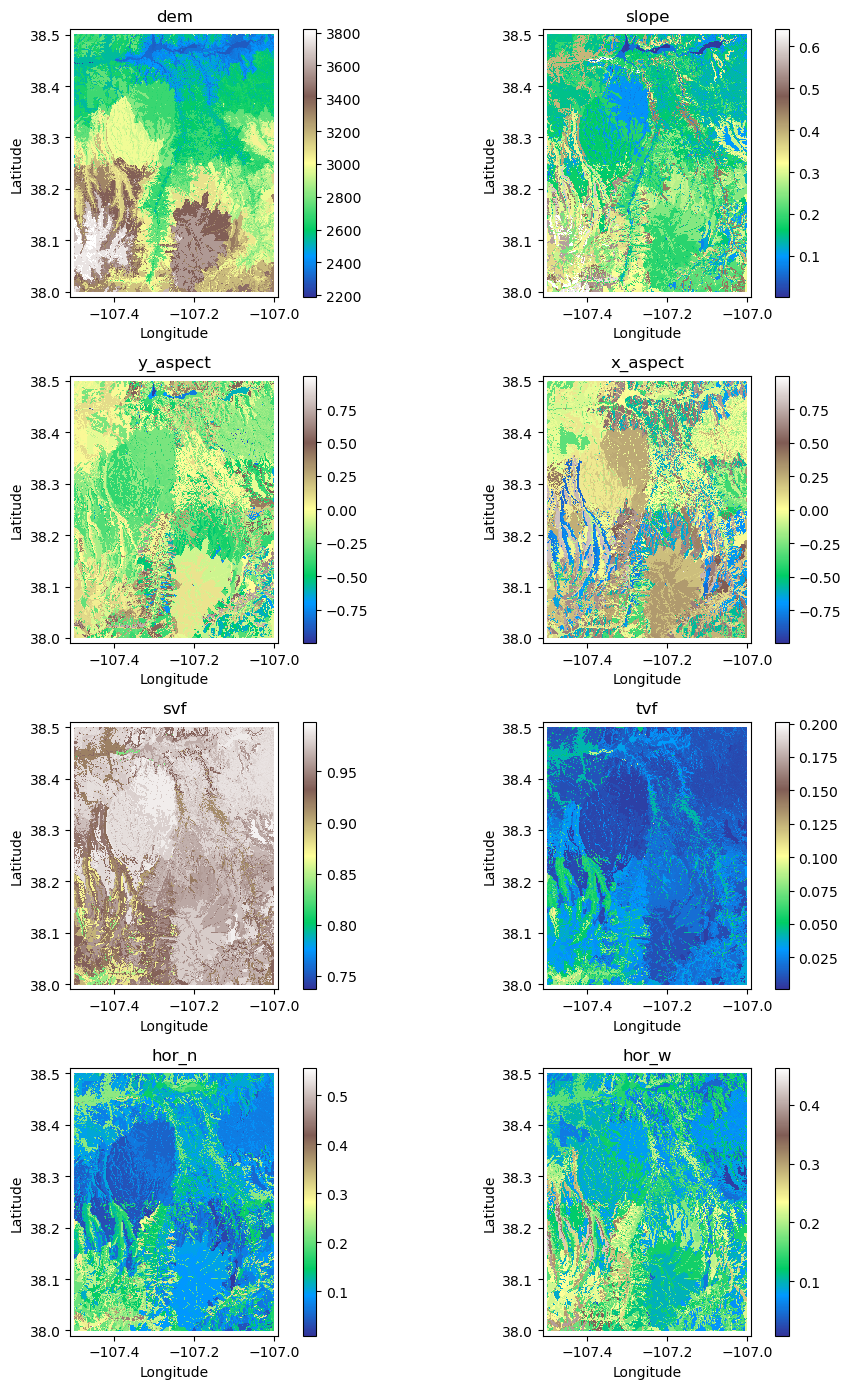

In [1]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import geospatialtools.gdal_tools as gdal_tools

# Output path
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

# Simulation path
path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_11yrs_100hru_100bh_test_new_test_domain/"

print(path)

# Read HRU and CID maps
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

print(f"Raster metadata: {metad}")

# Coordinate axes
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0
coords_y = coord_yy0

# ---------------------------------------------------------
# Load state/admin boundaries once, before plotting
# ---------------------------------------------------------
BOUNDARIES_SOURCE = "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_1_states_provinces.zip"

boundaries = None
try:
    boundaries = gpd.read_file(BOUNDARIES_SOURCE)
    print(f"Boundary layer loaded: CRS={boundaries.crs}, features={len(boundaries)}")
except Exception as error:
    print(f"Could not load boundaries: {error}")

# Diagnostic: what range are our raster coordinates actually in?
print(f"Raster x range: {coords_x.min()} to {coords_x.max()}")
print(f"Raster y range: {coords_y.min()} to {coords_y.max()}")
print(f"metad keys: {list(metad.keys())}")
# If the raster has a CRS/projection field in its metadata, print it too
for key in ("srs", "proj", "crs", "projection"):
    if key in metad:
        print(f"Raster {key}: {metad[key]}")

# Function to place HRU data on raster grid
def place_data(final_map, model, hrus, cids, val):
    for i in range(final_map.shape[0]):
        for j in range(final_map.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru != -9999) and (ucid == val):
                final_map[i, j] = model[hru]

    return final_map

# Variables to plot
var2plot = ["dem", "slope","y_aspect", "x_aspect","svf", "tvf","hor_n", "hor_w"]

cid_list = [1, 2, 3, 4]

# Plot
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
axes = axes.flatten()

for j, ax in enumerate(axes):

    var = var2plot[j]
    print(f"Plotting {var}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"{c}/input_file.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)

        grp = fp.groups["parameters"]
        data = np.array(grp.variables[var][:])

        fp.close()

        final_map = place_data(final_map, data, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    # Valid-data extent with small no-data border
    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="terrain",
        shading="auto"
    )

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    # ---------------------------------------------------------
    # Overlay state/admin boundaries, clipped to this panel's extent
    # ---------------------------------------------------------
    if boundaries is not None:
        clipped = boundaries.cx[
            (xmin - pad_x):(xmax + pad_x),
            (ymin - pad_y):(ymax + pad_y),
        ]

        if j == 0:  # only print this diagnostic once, not per-panel
            print(f"    Boundary features clipped to first panel's extent: {len(clipped)}")

        if not clipped.empty:
            clipped.boundary.plot(ax=ax, edgecolor="black", linewidth=0.6, zorder=3)
        elif j == 0:
            print("    WARNING: no boundary features in this extent -- "
                  "likely a CRS mismatch between the raster (Longitude/Latitude "
                  "axis labels suggest degrees) and the boundary file.")

    fig.colorbar(im, ax=ax)

plt.tight_layout()

outfile = os.path.join(outputdir, "res_terrain_test025_old_all_cids_new_boundaries.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()